In [6]:
import pickle
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# --------------------------------------------------
# 3. PINN model (predicts normalized temperature θ)
# --------------------------------------------------
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 512),
            nn.Tanh(),
            nn.Linear(512, 512),
            nn.Tanh(),
            nn.Linear(512, 1)
        )

    def forward(self, r):
        return self.net(r)

In [8]:
with open("pinn_pipe_model.pkl", "rb") as f:
    saved = pickle.load(f)

# Recreate model
model = PINN()
model.load_state_dict(saved["model_state_dict"])
model.eval()

# Restore parameters
R = saved["R"]
Tw = saved["Tw"]
Tc = saved["Tc"]
T_scale = saved["T_scale"]
Umax = saved["Umax"]

print("Model loaded successfully.")


Model loaded successfully.


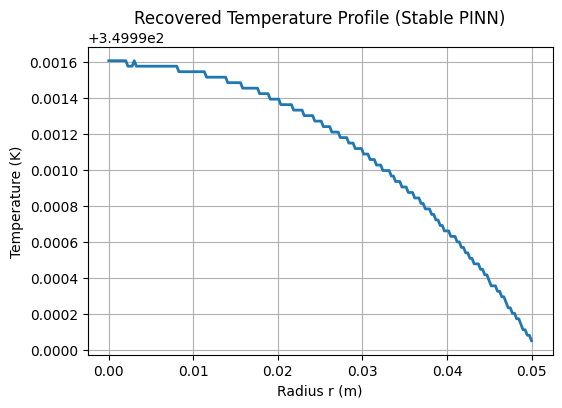

In [9]:
import torch
import numpy as np

r = torch.linspace(0, R, 200).view(-1, 1)

with torch.no_grad():
    theta = model(r)
    T = theta * T_scale + Tw

r_np = r.numpy()
T_np = T.numpy()
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.plot(r_np, T_np, lw=2)
plt.xlabel("Radius r (m)")
plt.ylabel("Temperature (K)")
plt.title("Recovered Temperature Profile (Stable PINN)")
plt.grid(True)
plt.show()


In [10]:
def velocity(r):
    return Umax * (1 - (r / R) ** 2)

u = velocity(r)
# Flatten all tensors to 1D for integration
r_flat = r.squeeze()
u_flat = u.squeeze()
T_flat = T.squeeze()

numerator = torch.trapz(u_flat * T_flat * r_flat, r_flat)
denominator = torch.trapz(u_flat * r_flat, r_flat)

T_indicated = numerator / denominator
print(f"Predicted thermometer reading: {T_indicated.item():.2f} K")


Predicted thermometer reading: 349.99 K
